#### A/B Testing Case Study

#### we want to test whether the experimental version of the landing page of this website is more engaging as compared to the current version(control), we will use the CTR ( Click Through Rate ) as the primary metric for this case 

#### SECURE FREE TRIAL v/s ENROLL NOW 

![Lunar Tech Screenshot](Lunar_Tech_SS.png)


#### Buisness Hypothesis : 

#### Null Hypothesis: "ENROLL NOW" has the same Click Through Rate (CTR) as "SECURE FREE TRIAL" 
#### Alternative Hypothesis :  "ENROLL NOW" has different Click Through Rate (CTR) than "SECURE FREE TRIAL" 

In [1]:
import pandas as pd 
import numpy as  np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm 

#### Loading Data

In [2]:
df = pd.read_csv(r"C:\Users\Pavitra\Downloads\A-B_Testing\ab_test_click_data (1).csv")

In [3]:
df.head()

,user_id,click,group,timestamp
0,1,1,exp,2024-01-01 00:00:00
1,2,0,exp,2024-01-01 00:01:00
2,3,1,exp,2024-01-01 00:02:00
3,4,0,exp,2024-01-01 00:03:00
4,5,1,exp,2024-01-01 00:04:00


In [4]:
df.tail()

,user_id,click,group,timestamp
19995,19996,1,con,NaN
19996,19997,1,con,NaN
19997,19998,1,con,NaN
19998,19999,0,con,NaN
19999,20000,1,con,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    20000 non-null  int64 
 1   click      20000 non-null  int64 
 2   group      20000 non-null  object
 3   timestamp  10000 non-null  object
dtypes: int64(2), object(2)
memory usage: 625.1+ KB


In [6]:
df_exp_count = df[df["click"] == 1].shape[0]


In [7]:
df_exp_count

8105

In [8]:
df.groupby("group").count()

,user_id,click,timestamp
group,,,
con,10000,10000,0
exp,10000,10000,10000


#### distribution of clicks across the 2 groups 

In [9]:
 df_grouped = df.groupby("group").sum("click")

In [10]:
 df_grouped

,user_id,click
group,,
con,150005000,1989
exp,50005000,6116


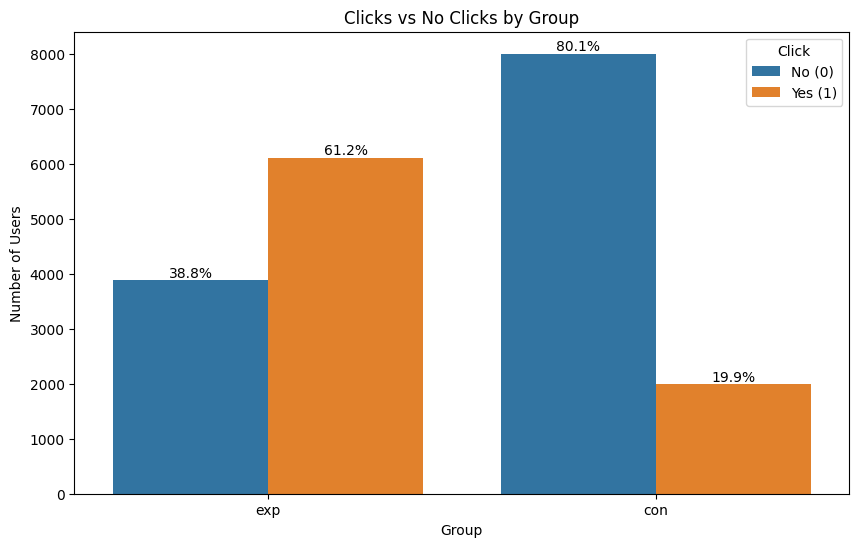

In [11]:
plt.figure(figsize = (10,6))


ax=sns.countplot(
    data=df,
    x="group",
    hue= "click"
)

plt.xlabel("Group")
plt.ylabel("Number of Users")
plt.title("Clicks vs No Clicks by Group")

total_per_group = df.groupby("group").size()

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            group = bar.get_x() + bar.get_width() / 2
            group_label = ax.get_xticklabels()[int(bar.get_x() + bar.get_width()/2)].get_text()
            percentage = height / total_per_group[group_label] * 100

            ax.annotate(
                f"{percentage:.1f}%",
                (bar.get_x() + bar.get_width() / 2, height),
                ha="center",
                va="bottom",
                fontsize=10
            )

plt.legend(title="Click", labels=["No (0)", "Yes (1)"])
plt.show()



#### Parameters of the Model from Power Analysis

![Power Analysis](Anotations.png)


In [12]:
alpha = 0.05  # 5%   
delta = 0.1   # 10%  (it only matters when the difference is above 10%)
# (atleast 10% higher CTR in the exp than the con to launch the new exp version i.e. practical significance)

### Calculating total number of clicks per group by summing clicks 

In [13]:
df.groupby("group")["click"].sum()

group
con    1989
exp    6116
Name: click, dtype: int64

In [14]:
X_con = df.groupby("group")["click"].sum().loc["con"]
X_exp = df.groupby("group")["click"].sum().loc["exp"]

In [15]:
X_con

np.int64(1989)

In [16]:
X_exp

np.int64(6116)

In [17]:
N_con = df[df["group"]=="con"]["user_id"].nunique()
N_exp = df[df["group"]=="exp"]["user_id"].nunique()

In [18]:
N_con

10000

In [19]:
N_exp

10000

### Calculating the Pooled Variance

In [20]:
p_con_hat = X_con/N_con
p_exp_hat = X_exp/N_exp
print("Click Probability in Control Group:" , (p_con_hat))
print("Click Probability in Experimental Group:" , (p_exp_hat))

Click Probability in Control Group: 0.1989
Click Probability in Experimental Group: 0.6116


In [21]:
# computing the estimate of the pooled clicked probability
p_pooled_hat = (X_con+X_exp)/(N_con+N_exp)
print("Pooled Clicked Probability :" , p_pooled_hat)

Pooled Clicked Probability : 0.40525


In [22]:
pooled_variance = (p_pooled_hat * (1-p_pooled_hat)) * (1/N_con + 1/N_exp)

In [23]:
print("Pooled_variance:" , pooled_variance)

Pooled_variance: 4.82044875e-05


### Calculating the Standard Error and Test Statistics

In [24]:
# standard error 

SE = np.sqrt(pooled_variance)
print("Standard Error is :" , SE)

Standard Error is : 0.006942945160376826


In [25]:
# test statistic = Z-test

test_stat = (p_con_hat - p_exp_hat)/SE
print("Test Statistic for 2-sample Z-test is:" , test_stat)

Test Statistic for 2-sample Z-test is: -59.44163326469381


In [26]:
# critical value of Z-test

Z_crit = norm.ppf(1-alpha/2) # two-tailed test
print("Z-test value from the Standard Normal distribution" , round((Z_crit),2))

Z-test value from the Standard Normal distribution 1.96


### Calculating p-values of the Z-Test

In [27]:
# confirming whether to accept or reject the nll hypothesis via the p-value

value = 2*norm.sf(abs(test_stat))

In [28]:
# function to chec=k the statistical significance 

def is_statistically_significant(p_value,alpha):
    print("p-value for the 2-Sample Z-test:" , round((value),3))

    if p_value <= alpha :
        print("There is statistical significance at 5% level of significance(alpha) ,indicating that the observed difference between the groups are unlikely to have \noccurrred due to random chance")
        print("The experimental version of the landing page is better than the control version")
        print("We reject the null hypothesis")
    else:
        print("There is no statistical significance , suggesting that the observed difference between the groups are likely to have occurrred due to random chance")
        print("There is not enough evidence to suggest that the CTR of the experimental version is different than the CTR of the control version")
        print("We do not reject the null hypothesis")

is_statistically_significant(value,0.05)

p-value for the 2-Sample Z-test: 0.0
There is statistical significance at 5% level of significance(alpha) ,indicating that the observed difference between the groups are unlikely to have 
occurrred due to random chance
The experimental version of the landing page is better than the control version
We reject the null hypothesis


### Visualization

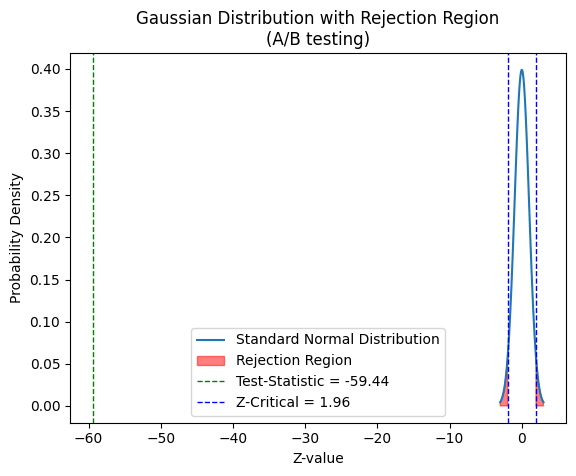

In [29]:

# Parameters of the Standard Normal Distribution 
mu = 0      # mean
sigma = 1   # standard deviation

x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
y = norm.pdf(x, mu, sigma)


# Plotting the Standard Normal Distribution 
plt.plot(x, y, label="Standard Normal Distribution")

# shading the rejection region
plt.fill_between(
    x, y,
    where=(x > Z_crit) | (x < -Z_crit),
    color='red',
    alpha=0.5,
    label="Rejection Region"
)

# adding the test_statistic
plt.axvline(test_stat,color="green",linestyle="dashed", linewidth=1, label=f"Test-Statistic = {test_stat:.2f}")

# adding the Z-critical values
plt.axvline(Z_crit, color="blue", linestyle="dashed", linewidth=1,
            label=f"Z-Critical = {Z_crit:.2f}")
plt.axvline(-Z_crit, color="blue", linestyle="dashed", linewidth=1)

# adding the labels and titles
plt.xlabel("Z-value")
plt.ylabel("Probability Density")
plt.title("Gaussian Distribution with Rejection Region\n(A/B testing)")
plt.legend()
plt.show()


###  Calculating the Confidence Interval of the test
### Assessing the statistical significance

In [30]:
CI_95 = [round((p_exp_hat - p_con_hat) - SE*Z_crit,3) # Lower Bound
 ,round((p_exp_hat - p_con_hat) + SE*Z_crit,3)] # Upper Bound

print(f"Confidence Interval {(1-alpha)*100}% at  of the 2-sample Z-test is: " ,CI_95)

Confidence Interval 95.0% at  of the 2-sample Z-test is:  [np.float64(0.399), np.float64(0.426)]


### Testing for Practical Significance in A/B Testing

In [32]:
print(delta)

0.1


In [34]:
def is_practically_significant(delta , CI_95):
    lower_bound_CI = CI_95[0]

    if lower_bound_CI >= delta:
        print(f"We have pratical significance!  \nwith MDE of {delta} \nThe differnce between the control and experimental is practically significant")
        return True
    else:
        print("We do not have practical significance! \nThe difference between Control and Experimental group is not practically significant.")
        return False

significance=is_practically_significant(delta , CI_95)
print("Since the Lower bound of the 95% CI is:" , CI_95[0])

We have pratical significance!  
with MDE of 0.1 
The differnce between the control and experimental is practically significant
Since the Lower bound of the 95% CI is: 0.399


In [35]:
if is_practically_significant(delta , CI_95):
    print("Yes !, we can go with new experimental version of the landing page")
else:
    print(" No !, we should stay with the control version of the landing page")

We have pratical significance!  
with MDE of 0.1 
The differnce between the control and experimental is practically significant
 Yes !, we can go with new experimental version of the landing page
